# ISB Practical 3 - 2025/26

## Assignment Technical details
Similar to Practical Report 2, please fill in the gaps in the code as indicated in the provided *Jupyter notebook* (folder 'Python computer practical' on ISB Blackboard) using Python 3 and, when finished, submit this notebook using the corresponding Dropbox link before the submission deadline. Following each question in the notebook, you find "cells" for your answers, indicated either as <span style='color:Blue'>code answer</span> or <span style='color:Blue'>text answer</span>. **Only the changes you do to those cells will be evaluated, and please do not temper with the rest of the notebook, and only the provided Jupyter notebook will be considered for marking.**

To complete the code for Practical Report 3, you need to understand the question (**Step 1**), the provided skeleton code (**Step 2**), and finally how to fill in the missing code (**Step 3**) using the variables etc from the remainder of the code. The skeleton mustn't be modified. Generally, the missing code should just be a few lines, and it is marked according to whether the report (code) runs, whether it provides the correct result, and whether the code is efficient (concise, elegant,...). Regarding the latter criterion, this means that code is brief/minimal using short meaningful variable names without unnecessary brackets, and based on the basic programming skills you learned in the first and second practical as well as the introductory Python sessions (to avoid copying and pasting complicated or sophisticated code you may have found online). Minimal amounts of comments for additional explanation using **#....** might be useful, while massive amounts should be avoided. Make also sure figures have readable axis labels and visible line styles. Text answers need to be concise within word limits and do not require external references - they test if you understood and can interpret your results. Before submitting, make sure your notebook runs as a whole on *Anaconda* and produces the correct result! As some questions are harder, it is not expected that every student will be able to answer all subquestions. **Maximal total score for Practical 3 is 100 points.**

## Exploring Turing patterns

In 1952, Alan Turing published his famous reaction-diffusion model for two interacting molecular species. Counter- intuitively, he found that diffusion can lead to structure and pattern formation. Here, we explore how the initial homogeneous state becomes unstable using first a single cell, then two cells, and finally a 1-dimensional (1d) lattice of cells.

<img src="turing_rob-phillips.png" width="500"/>

**FIG. 1:** Emergence of a Turing pattern for two interacting molecular species with diffusion in a pair of cells (A) and a 1d lattice of cells (B). Image thanks to Rob Phillips.

Consider a single cell with two molecular species (or morphogens),  activator $X$ and inhibitor $Y$, 
described by the following set of dynamic equations
\begin{eqnarray}
\frac{dX}{dt}&=&5X - 6Y + 1\\
\frac{dY}{dt}&=&6X - 7Y + 1,
\end{eqnarray}
where both $X$ and $Y$ are produced by $X$, along with some basal production, and degraded by $Y$. The steady state is $X=Y=1$, which is easily checked by setting $dX/dt=dY/dt=0$. 

**Question 1a:**  By imagining small deviations from the steady state via $X=1+x$ and $Y=1+y$, calculate the Jacobian matrix. Define this matrix in your code below (derivation not required) and calculate (and print) its eigenvalues $\lambda_{1,2}$ through matrix diagonalisation with the *numpy* library. (Code answer, 5 points)


In [1]:
#### Libraries
import numpy as np

# >>>>>> Students: answer Question 1a

M=np.array([ [5, -6],
             [6, -7]
           ])
    
w, _ = np.linalg.eig(M)  # eigenvalues
print(w.real)

# <<<<<<<

Feedback1a='PIII Q1a: '
Mark1a=0


[-1. -1.]


**Question 1b:** Explain whether the obtained steady state is stable or not. (Text answer - 20 words max, 5 points)


Both eigenvalues have a negative real part which means the steady state is stable.

In [2]:
Feedback1b='PIII Q1b:'
Mark1b=0

Now consider two cells (<span style='color:Blue'>Fig. 1A</span>), where $X$ and $Y$ can exchange via diffusion:
\begin{eqnarray}
\frac{dX_1}{dt}&=&5X_1 - 6Y_1 + 1 + D_X(X_2 - X_1)\\
\frac{dY_1}{dt}&=&6X_1 - 7Y_1 + 1 + D_Y(Y_2 - Y_1)\\
\frac{dX_2}{dt}&=&5X_2 - 6Y_2 + 1 + D_X(X_1 - X_2)\\
\frac{dY_2}{dt}&=&6X_2 - 7Y_2 + 1 + D_Y(Y_1 - Y_2),
\end{eqnarray}
where subscripts 1 and 2 refer to cells 1 and 2, and $D_X$ ($D_Y$) is the diffusion constant for species $X$ ($Y$) according to Fick's law.

**Question 1c:** For a pair of cells with steady state $X_1=X_2=Y_1=Y_2=1$, explore the stability as a function of the diffusion constant $D_Y$. For this purpose, set $D_X=0.5$ and plot largest eigenvalue for $D_Y$ from 
0.5 to 5. (Code answer, 10 points)

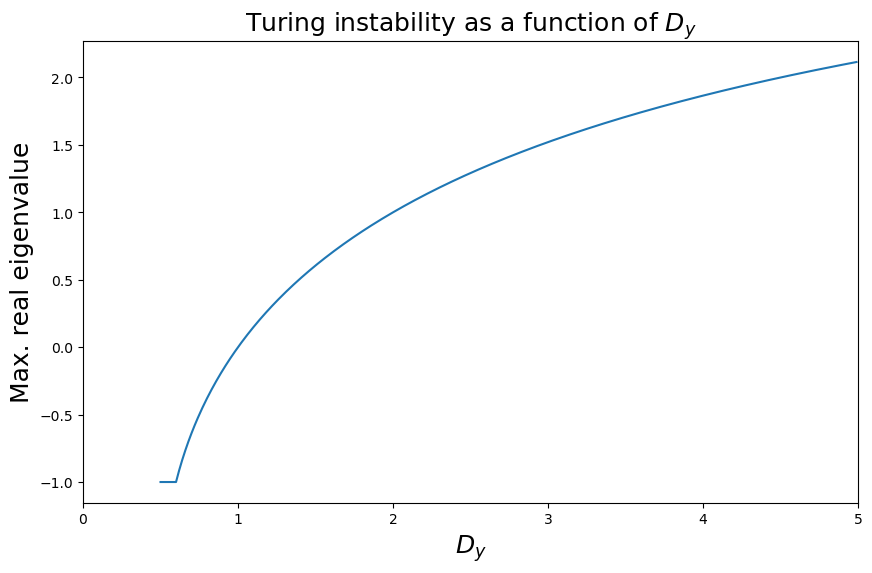

In [3]:
#### Libraries
import numpy as np
import matplotlib.pyplot as plt


# >>>>>> Students: answer Question 1c

#parameter values
Dx=0.5
Dy = np.arange(0.5, 5, 0.01) # numerical grid
        
L=[]
for i in range(len(Dy)):
    
    M=np.array([ [5-Dx,    -6,       Dx,    0],
                 [6,    -7-Dy[i],    0,     Dy[i]],
                 [Dx,      0,        5-Dx,  -6],
                 [0,       Dy[i],    6,     -7-Dy[i]]
               ])
    
    w, _ = np.linalg.eig(M)  # eigenvalues
    L.append(max(w.real))
    

# Plot
plt.figure(figsize = (10, 6))
plt.plot(Dy, L)
plt.xlim(0, 5)
plt.title("Turing instability as a function of $D_y$",fontsize=18)
plt.ylabel("Max. real eigenvalue",fontsize=18)
plt.xlabel("$D_y$",fontsize=18)
plt.show()

# <<<<<<

Feedback1c='PIII Q1c: '
Mark1c=0

**Question 1d:** Explain result briefly (Text answer - 30 words max, 5 points)

For $D_y$ larger than about 1 and hence sufficiently faster than $D_x$, the system becomes Turing unstable with an eigenvalue having a positive real part. The horizonal line is likely due to crossing of eigenvalues as always take real largest.

In [4]:
Feedback1d='PIII Q1d: '
Mark1d=0

Now consider a 1d lattice of cells (<span style='color:Blue'>Fig. 1B</span>) with linearised equations for cell $r$ given by
\begin{eqnarray}
\frac{dx_r}{dt}&=&A_1x_r + B_1y_r + D_X(x_{r+1} + x_{r-1} - 2x_r)\\
\frac{dy_r}{dt}&=&A_2x_r + B_2y_r + D_Y(y_{r+1} + y_{r-1} - 2y_r),
\end{eqnarray}
where coefficients $A_1$, $B_1$, $A_2$, and $B_2$ are given by partial derivatives of nonlinear functions (Jacobian matrix). Plugging in trial solution $x_r(t)=x(t)e^{i2\pi r/\lambda}$ and $y_r(t)=y(t)e^{i2\pi r/\lambda}$ with wavelength of perturbation 
$\lambda$ produces  
\begin{eqnarray}
\frac{dx}{dt}&=&\left[A_1 + D_X\left(e^{i2\pi/\lambda}+e^{-i2\pi/\lambda}-2\right)\right]x + B_1y\\
\frac{dy}{dt}&=&A_2x + \left[B_2 + D_Y\left(e^{i2\pi/\lambda}+e^{-i2\pi/\lambda}-2\right)\right]y.
\end{eqnarray}

**Question 1e:** Assuming $\lambda>\!\!>1$, use Taylor expansion $e^x\approx 1+x+x^2/2$ to simplify above equations (derivation does not need to be presented). Show that there is a wave-length specific instability by plotting largest eigenvalue (real part) as a function of $\lambda$. Use $A_1=1$, $B_2=-1$, $A_2=1$, $B_1=-1$, $D_X=1$ and $D_Y=100$. (Code answer, 10 points)


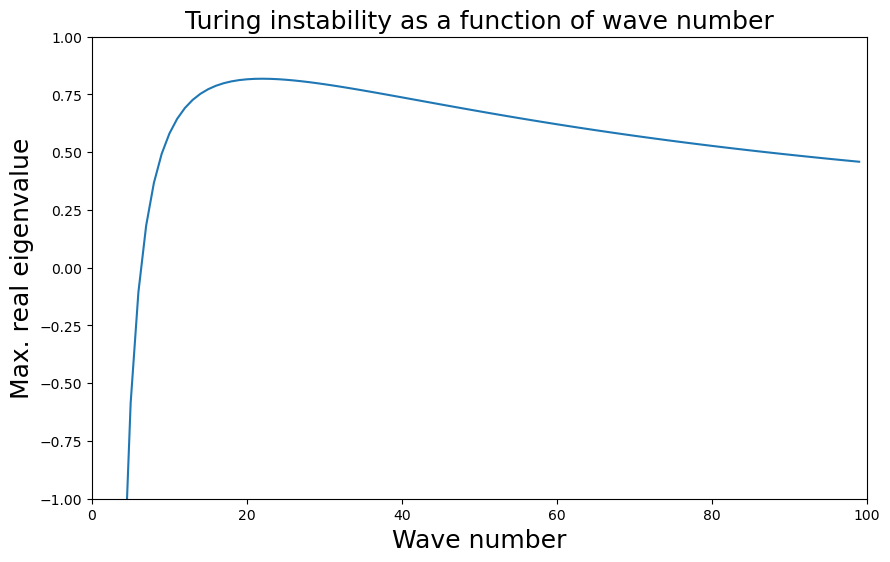

In [5]:
#### Libraries
import numpy as np
import matplotlib.pyplot as plt
import math

# parameters
pi = math.pi
A1=1
B2=-1
Dx=1
Dy=100
A2=1
B1=-1


# >>>>>> Students: answer Question 1e

L = np.arange(1, 100, 1) # wave length lambda

E=[]

for i in range(len(L)):

    M=np.array([  [A1-Dx*(2*pi/L[i])**2, B1],
                  [A2,  B2-Dy*(2*pi/L[i])**2]
               ])

    w, _ = np.linalg.eig(M)  # eigenvalues
    E.append(max(w.real))
    

# Plot
plt.figure(figsize = (10, 6))
plt.plot(L, E)
plt.xlim(0, 100)
plt.ylim(-1, 1)
plt.title("Turing instability as a function of wave number",fontsize=18)
plt.ylabel("Max. real eigenvalue",fontsize=18)
plt.xlabel("Wave number",fontsize=18)
plt.show()

# <<<<<<<<<


Feedback1e='PIII Q1e: '
Mark1e=0


**Question 1f:** Explain result. (Text answer - 30 words max, 5 points)

For wave numbers around 5 the steady state becomes unstable with an eigenvalue having a positive real part. The peak and hence maximal initial instability is around wave number 25.

In [6]:
Feedback1f='PIII Q1f: '
Mark1f=0

## Toggle gene switch

Do bistable gene circuits alaways require cooperativity? Consider the toggle switch, a well-known
gene circuit of two mutually inhibiting genes shown in Fig. 2. There are two promoters, $p_A$
and $p_B$, and their respective gene products, proteins $A$ and $B$. There are negative feedbacks
in which $A$ can bind $p_B$ and inhibit expression of $B$, and $B$ can bind $p_A$ and inhibit
expression of $A$.

<img src="toggle_switch.png" width="500"/>

**Fig. 2:** Toggle switch with two promoters, two genes, and two proteins, mutually repressing each other.

The elementary chemical reactions are as follows:

<img src="toggle_eqs.png" width="250"/>

where the first reaction is degradation of $A$ with rate constant $d_A$, the second is production of $A$ from active promotor $\alpha$ with rate constant $k_A$, the third is degradation of $B$ with rate constant $d_B$, 
the forth is production of $B$ from active promotor $\beta$ with rate constant $k_B$, the fifth is inhibition
of $\alpha$ into inactive form $\alpha^*$, and sixth is inhibition of $\beta$ into inactive form $\beta^*$ with rate constants as indicated.

__Question 2a:__ Implement a Gillespie simulation of this system by simulating
all eight elementary reactions (where the copy number of a species changes by at most one molecule) 
using symmetric parameter values $d_a=d_B=d=10$/s, $k_A=k_B=k=100$/s, $f_A=f_B=f=0.1$/s, and $r_A=r_B=r=0.01$/s. (Code answer, 15 points)


In [7]:
import numpy as np
   
# Parameters
d=10 #/s
k=100
f=0.1
rr=0.01

t0 = 0 # initialise
a0 = 1
A0 = 1
b0 = 1
B0 = 1

steps = 100000   # Number of time steps per trajectory

# Set up holder numpy arrays
t = np.zeros(steps+1)
a = np.zeros(steps+1)
A = np.zeros(steps+1)
b = np.zeros(steps+1)
B = np.zeros(steps+1)

# Store initial conditions
t[0] = t0
a[0] = a0
A[0] = A0
b[0] = b0
B[0] = B0

# >>>>>> Students: answer Question 2a (use one for loop)

# Main loop

for i in range(steps):
     
    # Calculate updated reaction rates
    rates=[d*A[i], k*a[i], d*B[i], k*b[i], f*B[i]*a[i], (1-a[i])*rr, f*A[i]*b[i], (1-b[i])*rr]
    rtot=rates/np.sum(rates) # normalised rates
    rcum=np.cumsum(rtot) # cumulative sum
        
    # Select which reaction to occur
    R1 = np.random.random()
        
    # Update populations
    if  R1<rcum[0]:
        A[i+1] = A[i] - 1
        a[i+1]=a[i]
        b[i+1]=b[i]
        B[i+1]=B[i]
                
    elif rcum[0]<=R1 and R1<rcum[1]:
        A[i+1] = A[i] + 1
        a[i+1]=a[i]
        b[i+1]=b[i]
        B[i+1]=B[i]
        
    elif rcum[1]<=R1 and R1<rcum[2]:
        B[i+1] = B[i] - 1
        a[i+1]=a[i]
        b[i+1]=b[i]
        A[i+1]=A[i]
        
    elif rcum[2]<=R1 and R1<rcum[3]:
        B[i+1] = B[i] + 1
        a[i+1]=a[i]
        b[i+1]=b[i]
        A[i+1]=A[i]
        
    elif rcum[3]<=R1 and R1<rcum[4]:
        a[i+1]=a[i]-1
        B[i+1]=B[i]-1
        b[i+1]=b[i]
        A[i+1]=A[i]
        
    elif rcum[4]<=R1 and R1<rcum[5]:
        a[i+1]=a[i]+1
        B[i+1]=B[i]+1
        b[i+1]=b[i]
        A[i+1]=A[i]
    
    elif rcum[5]<=R1 and R1<rcum[6]:
        b[i+1]=b[i]-1
        A[i+1]=A[i]-1
        a[i+1]=a[i]
        B[i+1]=B[i]
        
    else :
        b[i+1]=b[i]+1
        A[i+1]=A[i]+1
        a[i+1]=a[i]
        B[i+1]=B[i]
        
            
    # Calculate time to next reaction
    R2 = np.random.random()
    tau = 1/np.sum(rates) * np.log(1/R2)
        
    # Store reaction time
    t[i+1] = t[i] + tau
        
        
# <<<<<<

Feedback2a='PIII Q2a: '
Mark2a=0

**Question 2b:** Plot time traces of protein numbers $A$ and $B$ in red and green in one plot, as well as histograms of $A$ and $B$. Do we have a bistable system? (Code answer, 5 points).

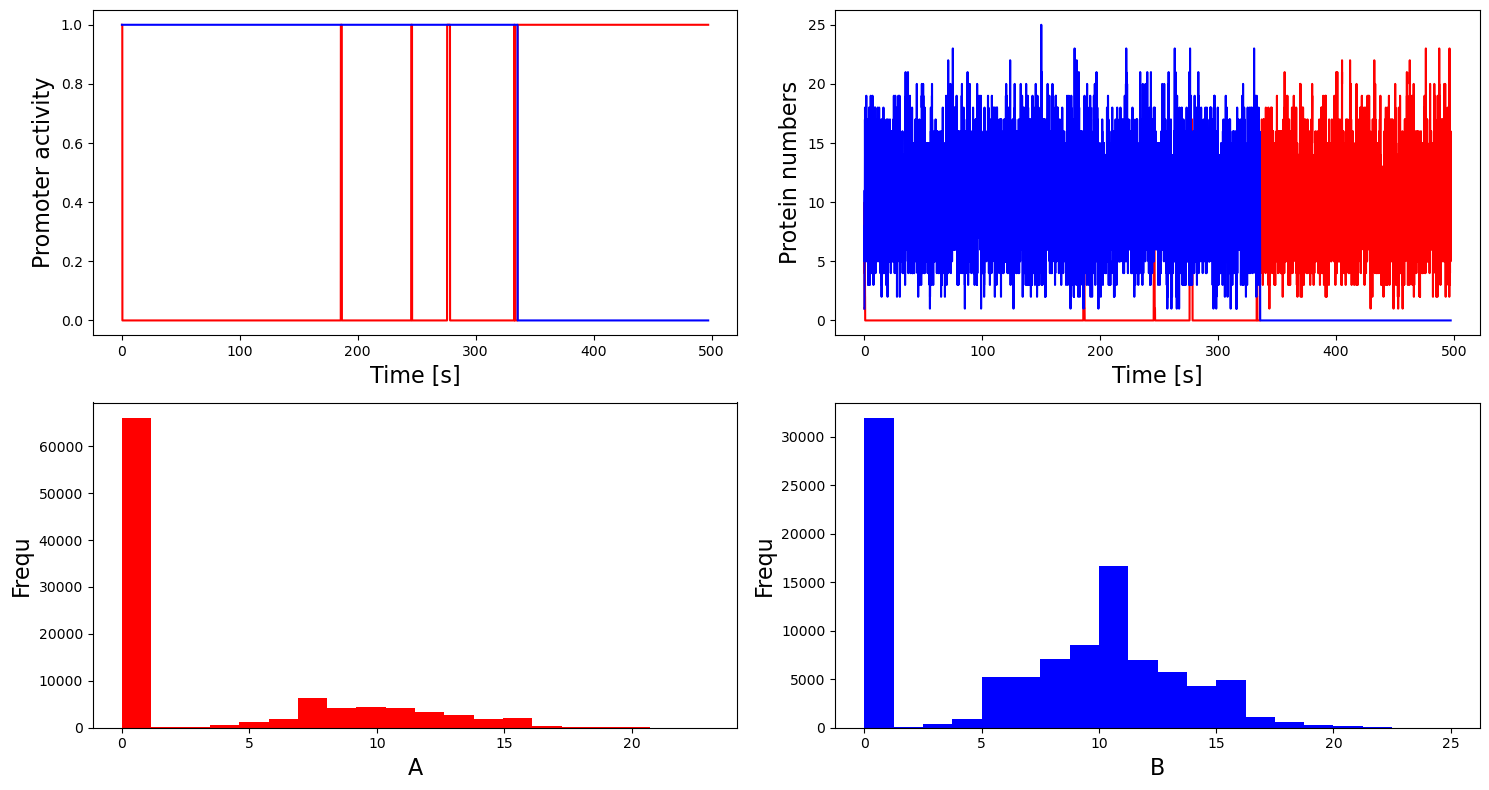

In [8]:
import matplotlib.pyplot as plt

# >>>>> Students: answer Question 2b here

plt.figure(figsize = (15, 8))
plt.subplot(221)
plt.plot(t,a,'red')
plt.plot(t,b,'blue')
plt.xlabel('Time [s]',fontsize=16)
plt.ylabel('Promoter activity',fontsize=16)

plt.subplot(222)
plt.plot(t,A,'red')
plt.plot(t,B,'blue')
plt.xlabel('Time [s]',fontsize=16)
plt.ylabel('Protein numbers',fontsize=16)

plt.subplot(223)
plt.hist(A,bins=20,color='red')
plt.xlabel('A',fontsize=16)
plt.ylabel('Frequ',fontsize=16)

plt.subplot(224)
plt.hist(B,bins=20,color='blue')
plt.xlabel('B',fontsize=16)
plt.ylabel('Frequ',fontsize=16)

plt.tight_layout()
plt.show()


# <<<<<<<<

Feedback2b='PIII Q2b: '
Mark2b=0

To explore bistability from a different angle, let's investigate the fixed points in the corresponding 
deterministic problem in which $A$, $\alpha$, $B$, and $\beta$ now correspond to their average values. 
The simplified time evolutions for $A$ and $\alpha$ are given by

$\frac{dA}{dt}=-dA\ +\ k \alpha$

$\frac{d\alpha}{dt}=r(1-\alpha)\ -\ fB\alpha$ 

where, in the first equation, we neglected terms due to binding and unbinding of $A$ to $\beta$ since
$A$ is assumed large. Also, we assumed there is a single copy of $\alpha$.

__Question 2c:__ Write down analogous equations for $B$ and $\beta$. Now transfer this
four-equation system to an even simpler two-equation system for only $A$ and $B$ by assuming 
promoter dynamics are much faster than gene expression, hence setting their time derivatives to
zero at quasi steady state. Derive both nullclines as $A(B)$ (i.e. A as a function of B). In standard math or Latex notation, write down the two-equation ODE model and equations for the steady-state nullclines. How many intersects (fixed points) do you have? (You can also look at the next plot.) How can this result be reconciled with your result from the Gillespie simulations? (Text answer max. 100 words, 10 points)

Two equation model (using algebra rules, notation a=alpha, b=beta, omitting * symbols for clarity):

dA/dt=kr/(r+fB)-dA

dB/dt=kr/(r+fA)-dB

--> nullclines:

A1(B)=kr/d/(r+fB)

A2(B)=r(k/(dB)-1)/f

One intersect only. There are different types of bistability. In the Gillespie, bistability is cause by slow promoter switching. As deterministic, this is not reflected in the nullclines.


In [9]:
Feedback2c='PIII Q2c: '
Mark2c=0

__Question 2d:__ Plot two nullclines. (Coding answer, 5 points)

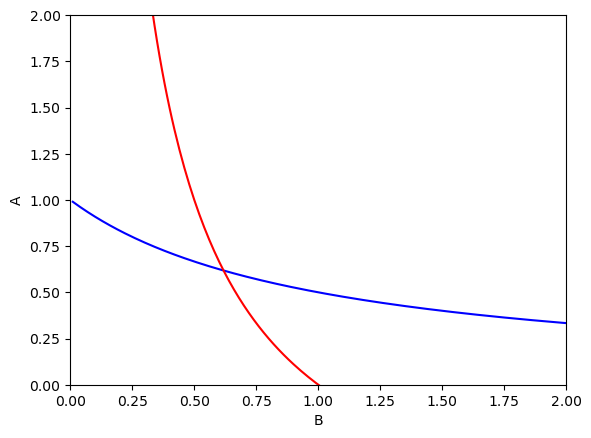

In [10]:
import numpy as np
import matplotlib.pyplot as plt

d=100 #/s
k=100
f=0.01
rr=0.01

# >>>>>> Students: answer Question 2d here

B = np.arange(0.01, 10, 0.01) 
        
A1=k*rr/d/(rr+f*B)
A2=(k/(d*B)-1)*rr/f

plt.plot(B,A1,color='blue')
plt.plot(B,A2,'red')
plt.xlabel('B')
plt.ylabel('A')
plt.xlim(0,2)
plt.ylim(0,2)
plt.show()

# <<<<<<<<

Feedback2d='PIII Q2d: '
Mark2d=0

__Question 2e:__ How can the two-equation model above be minimally modified to produce 
bistable behaviour? Plot the nullclines of the modified model to demonstrate this. (Coding answer, 5 points)

/var/folders/12/54cl0fj94jg9267ffkgp3m900000gn/T/ipykernel_94315/338409725.py:15: RuntimeWarning: invalid value encountered in power
  A2=((k/(d*B)-1)*rr/f)**(1/n)


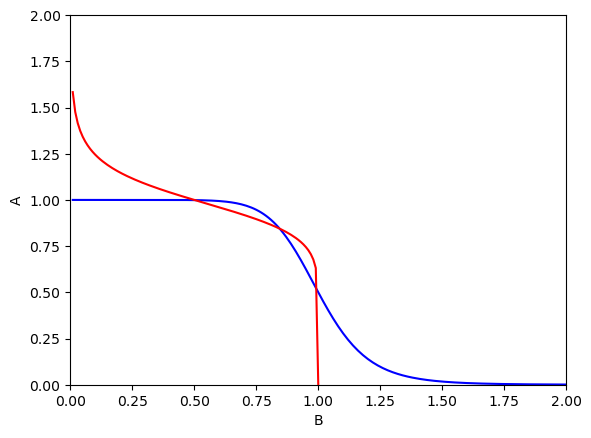

In [11]:
import numpy as np
import matplotlib.pyplot as plt

d=100 #/s
k=100
f=0.01
rr=0.01
n=10

# >>>>>> Students: answer Question 2e here

B = np.arange(0.01, 10, 0.01) 
        
A1=k*rr/d/(rr+f*B**n) # add Hill coefficients to increase sensitivity to repressors
A2=((k/(d*B)-1)*rr/f)**(1/n)

plt.plot(B,A1,color='blue')
plt.plot(B,A2,'red')
plt.xlabel('B')
plt.ylabel('A')
plt.xlim(0,2)
plt.ylim(0,2)
plt.show()

# <<<<<<<<

Feedback2e='PIII Q2e: '
Mark2e=0


## Hill-based perceptron as a gene circuit

The perceptron is one of the most fundamental building blocks of modern machine learning. It takes a set of input values, applies weights to them, sums them up, and passes the result through a nonlinear function (such as a sigmoid) to produce an output. This simple structure underlies more complex systems like neural networks, which form the core of deep learning. 

But perceptrons are not just a mathematical abstraction — they can also be biologically implemented using gene regulatory networks. By designing chemical reaction systems that mimic weighted input integration and thresholded output production, we can build biochemical circuits that process information in a way similar to artificial neurons. This opens exciting possibilities in synthetic biology, where living cells can be programmed to perform logical decisions, signal processing, or even learning-like behaviour.

In this practical question, we explore a gene circuit that behaves like a Hill-type perceptron — taking weighted molecular inputs and producing a sigmoidal output through a series of reactions. The chemical reaction system is shown below.

The reaction system below is designed to emulate the structure of a perceptron using biochemical components. Each input $x_i$ stimulates production of a common signalling molecule $S$ through a catalytic interaction with an enzyme-like species $A_i$, where the production rate $γ_i$ reflects the weight of input $x_i$. These signals are pooled into a shared molecular species $S$, whose concentration encodes a weighted sum of the inputs.

To create a nonlinear (sigmoidal) response, the system uses dimerisation of $S$ to form an active dimer $D$, which can then bind to a promoter $G$ and drive expression of an output protein $y$. This multi-step process introduces a Hill-like nonlinearity — a key feature of perceptrons — and allows the circuit to act as a biological decision-making unit. The output is degraded at a fixed rate, ensuring that the system reaches a steady state.

Together, these reactions implement a perceptron where the output depends on a nonlinear function of a weighted sum of inputs — mimicking the core operation of an artificial neuron, but built entirely from mass-action chemistry. Here is the chemical reaction network:

\begin{aligned}
x_i + A_i &\xrightarrow{\gamma_i} S + A_i \quad \text{(input-weighted signal production)} \\\\
S &\xrightarrow{\lambda} \emptyset  \quad \text{(decay of signalling molecule)} \\\\
S + S &\underset{k_r}{\overset{k_f}{\rightleftharpoons}} D \quad \text{(signal dimerisation)} \\\\
G + D &\underset{k_{\text{off}}}{\overset{k_{\text{on}}}{\rightleftharpoons}} G_D \quad \text{(promoter binding)} \\\\
G_D &\xrightarrow{\alpha} G_D + y \quad \text{(output production)} \\\\
y &\xrightarrow{\beta} \emptyset \quad \text{(output degradation)}
\end{aligned}

__Question 3a:__ Write the corresponding ODE system, i.e. $dS/dt=...$, $dD/dt=...$, $dG_D/dt=...$, and $dy/dt=...$ using Latex syntax (note when you run the markdown cell it needs to format correctly to produce the equations as you intended. (Text answer, 5 points)

Answer: 
dS/dt=\sum_i\gamma_i x_i A_i - 2k_fS^2+2k_r D-\lambda_S, 
dD/dt=k_fS^2 - k_rD-k_\text{on}DG+k_\text{off}G_D, 
dG_D/dt=k_\text{on}DG-k_\text{off} G_D, 
dy/dt=\alpha G_D - \beta y

In [12]:
Feedback3a='PIII Q3a: '
Mark3a=0

__Question 3b:__ Consider these at steady state and derive the final output $y^*$. Show only the final expression in the form of
\begin{equation}
y^*=A \frac{s^2}{K+s^2}
\end{equation}
using Latex syntax. Note specify the placeholder expressions $A$, $K$, and $s$ in terms of model variables and parameters. (Text answer, 5 points)

Answer:
A=\alpha G_\text{tot}/\beta, 
K=K_D K_d with K_D=k_\text{off}/k_\text{on} and k_d=k_r/k_f, 
s=\sum_i\omega_i x_i with \omega_i=\gamma_i A_i/\lambda

In [13]:
Feedback3b='PIII Q3b: '
Mark3b=0

__Question 3c:__ Now, we use the Hill function as a classifier based on the simplified expression:

$$
y^* = \frac{s^2}{K + s^2}, 
$$

where we use your expression for $s$ from above. We classity as:

- If $y^* > 0.5$, classify the input as **positive** (output 1)
- If $y^* \leq 0.5$, classify the input as **negative** (output 0)

Using this, we would like to implement a Hill-like perceptron and, based on 2D synthetic data in form of $[x_1, x_2]$ and a label, train it by backpropagation to work as a classifer, dividing combinations of inputs into low and high activation output. Specifically, we evaluate the output of the perceptron over a grid of $x_1$ and $x_2$ values using initial guesses for the weights $\mathbf{w}=[2,−1]$.

Training works as follows: To learn the correct weights $\mathbf{w}$, we use a simple gradient-based update rule inspired by backpropagation. First, define the prediction error:

$$
\text{error} = y_{\text{true}} - y^*
$$

To update each weight $w_i$, we apply the chain rule:

$$
\frac{\partial y^*}{\partial w_i} = \frac{dy^*}{ds} \cdot \frac{ds}{dw_i} = \frac{dy^*}{ds} \cdot x_i
$$

The derivative of the Hill activation function is:

$$
\frac{dy^*}{ds} = \frac{2K s}{(K + s^2)^2}.
$$

This leads to the following weight update rule for each $i$:

$$
w_i \leftarrow w_i + \eta \cdot (y_{\text{true}} - y^*) \cdot \frac{2K s x_i}{(K + s^2)^2}
$$

with $\eta$ the learning rate. Using this rule we can iteratively update the weights based on training data.

The task is to learn a decision boundary using a perceptron-like update but with a Hill activation function. Specifically, we want to plot the training loss as a function of epochs (training iterations), as well as the decision or activation landscape. The shape should confirm the nonlinearity and thresholding behaviour expected from a Hill function with squared input sum. In the coding cell below, please fill in the gaps to make the code work as intended. (Code answer, 5 points)

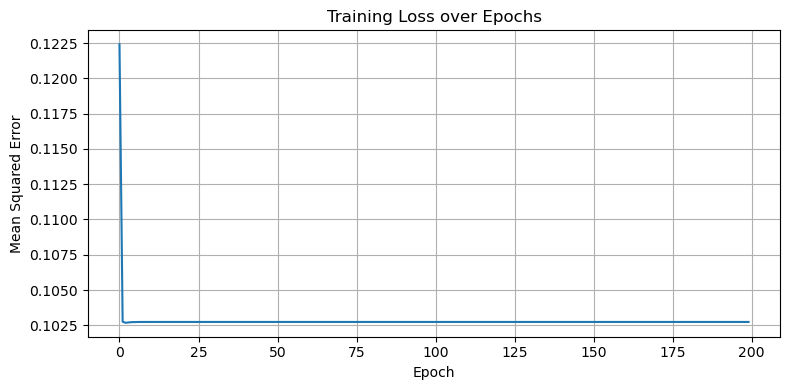

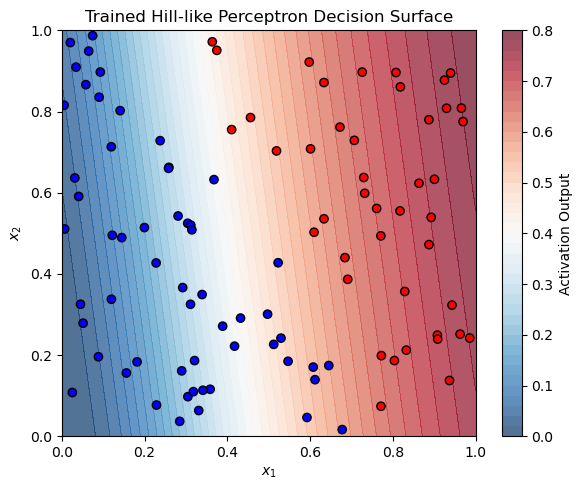

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Hill activation function and derivative ---
def hill_activation(s, K=1.0):
    return (s ** 2) / (K + s ** 2)

def hill_activation_derivative(s, K=1.0):
    return 2 * K * s / (K + s ** 2) ** 2

# --- Predict output and class ---
def predict_output(x, w, K=1.0):
    s = np.dot(w, x)
    return hill_activation(s, K)

def predict_class(x, w, K=1.0):
    return 1 if predict_output(x, w, K) > 0.5 else 0

# >>>>>> Students: answer Question 3c by filling in the gap in the loop

# --- Training using simple backpropagation ---
def train_perceptron(X, Y, w_init, K=1.0, eta=0.1, epochs=1000):
    w = w_init.copy()
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for x, y_true in zip(X, Y): # zip(X,Y) keeps input arrays and labels together in the training loop
            
            # >>>> complete this section only - want updated weights and total training loss as accumulated squared error <<<<
            s = np.dot(w, x)
            y_pred = hill_activation(s, K)
            error = y_true - y_pred
            grad = hill_activation_derivative(s, K) * np.array(x)
            w += eta * error * grad
            total_loss += error ** 2
            # <<<<< 
            
        loss_history.append(total_loss / len(X)) # mean squared error
    
    return w, loss_history

#<<<<<<<

# --- Generate synthetic data ---
np.random.seed(42)
n_samples = 100
X = np.random.uniform(0, 1, (n_samples, 2))
Y = np.array([1 if x[0] + 0.5 * x[1] > 0.75 else 0 for x in X])  # Simple linear separation


# --- Initialize weights ---
w_init = np.random.randn(2)

# --- Train perceptron ---
w_trained, loss_history = train_perceptron(X, Y, w_init, K=1.0, eta=0.5, epochs=200)

# --- Plot training loss ---
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot decision boundary ---
x1_vals = np.linspace(0, 1, 200)
x2_vals = np.linspace(0, 1, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

Z = np.array([[predict_output([x1, x2], w_trained) for x1, x2 in zip(row1, row2)]
              for row1, row2 in zip(X1, X2)])

plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, Z, levels=50, cmap='RdBu_r', alpha=0.7)
plt.colorbar(label='Activation Output')
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor='k', cmap='bwr', marker='o')
plt.title('Trained Hill-like Perceptron Decision Surface')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [15]:
Feedback3c='PIII Q3c: '
Mark3c=0

__Question 3d:__ Here we would like to compare static and dynamic perceptron outputs. In earlier parts of the practical, we used the quasi-steady state assumption for the perceptron output:

$$
y^* = \frac{s^2}{K + s^2}
$$

This can be used to simulate the response of a slow species $z(t)$ using:

$$
\frac{dz}{dt} = \gamma y^* - \delta z
$$

which assumes that $y^*$ is constant and reaches its value instantaneously.


In this subquestion, we consider a more biologically realistic case where $y(t)$ itself evolves dynamically:

$$
\begin{aligned}
\frac{dy}{dt} &= \alpha \cdot \frac{s^2}{K + s^2} - \beta y \\
\frac{dz}{dt} &= \gamma y - \delta z
\end{aligned}
$$


Implement the coupled ODE system for $y(t)$ and $z(t)$, and compare this to the simpler model using constant $y^*$, by integrating $dz/dt$ with `odeint`numerically. Plot both $z(t)$ curves on the same graph. Use parameters such as $\alpha = 1$, $\beta = 1$, $\gamma = 1$, $\delta = 0.5$, and weights $w = [2.0, 1.0]$, inputs $x = [1.0, -1.0]$. (Code answer, 5 points)

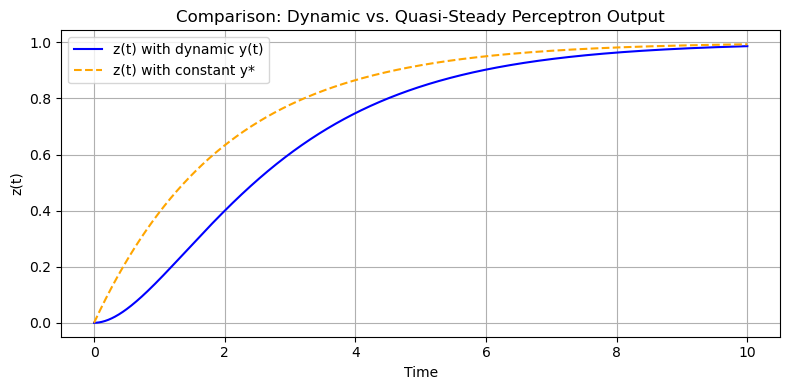

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
K = 1.0
alpha = 1.0
beta = 1.0
gamma = 1.0
delta = 0.5

# Input and weights
x = np.array([1.0, -1.0])
w = np.array([2.0, 1.0])
s = np.dot(w, x)

# Initial conditions
y0 = 0.0
z0 = 0.0
y_star = s**2 / (K + s**2)

# Time vector
T = 10
dt = 0.01
t = np.arange(0, T + dt, dt)

# >>>>>> Students: answer Question 3d by filling in the gaps

# Hint: Define the ODE system for y(t), z(t), and solve for z_dyn and z_qs

def dydz_dt(Y, t, s):
    y, z = Y
    dy = alpha * s**2 / (K + s**2) - beta * y
    dz = gamma * y - delta * z
    return [dy, dz]

# Solving the coupled ODE using odeint
Y0 = [y0, z0]
sol = odeint(dydz_dt, Y0, t, args=(s,))
y_dyn, z_dyn = sol.T

# Solving dz/dt = gamma * y* - delta * z using Euler method
z_qs = np.zeros_like(t)
z_qs[0] = 0.0
for i in range(1, len(t)):
    dzdt = gamma * y_star - delta * z_qs[i-1]
    z_qs[i] = z_qs[i-1] + dt * dzdt
    
# <<<<<<

#Plot and compare z(t) for both models
plt.figure(figsize=(8, 4))
plt.plot(t, z_dyn, label='z(t) with dynamic y(t)', color='blue')
plt.plot(t, z_qs, label='z(t) with constant y*', color='orange', linestyle='--')
plt.xlabel('Time')
plt.ylabel('z(t)')
plt.title('Comparison: Dynamic vs. Quasi-Steady Perceptron Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [17]:
Feedback3d='PIII Q3d: '
Mark3d=0

In [18]:
# print all feedback and marks

print(Feedback1a)
print(Mark1a)

print(Feedback1b)
print(Mark1b)

print(Feedback1c)
print(Mark1c)

print(Feedback1d)
print(Mark1d)

print(Feedback1e)
print(Mark1e)

print(Feedback1f)
print(Mark1f)




print(Feedback2a)
print(Mark2a)

print(Feedback2b)
print(Mark2b)

print(Feedback2c)
print(Mark2c)

print(Feedback2d)
print(Mark2d)

print(Feedback2e)
print(Mark2e)




print(Feedback3a)
print(Mark3a)

print(Feedback3b)
print(Mark3b)

print(Feedback3c)
print(Mark3c)

print(Feedback3d)
print(Mark3d)



total_mark=Mark1a+Mark1b+Mark1c+Mark1d+Mark1e+Mark1f + Mark2a+Mark2b+Mark2c+Mark2d+Mark2e + Mark3a+Mark3b+Mark3c+Mark3d
print('total: ',total_mark)

PIII Q1a: 
0
PIII Q1b:
0
PIII Q1c: 
0
PIII Q1d: 
0
PIII Q1e: 
0
PIII Q1f: 
0
PIII Q2a: 
0
PIII Q2b: 
0
PIII Q2c: 
0
PIII Q2d: 
0
PIII Q2e: 
0
PIII Q3a: 
0
PIII Q3b: 
0
PIII Q3c: 
0
PIII Q3d: 
0
total:  0
